# Questioning DARE - is Abstinence Only Education Truly Effective?
Nadia Synyavska

Repository Link - [nsynyavska23.github.io](https://github.com/nsynyavska23/nsynyavska23.github.io)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
import seaborn as sns
pd.set_option('display.max_rows', None, 'display.max_columns', None)

# Main Research Questions
*   Did youth substance use significantly decrease between the years 2002-2019 after DARE and other drug prevention programs became widely adopted?
*  Do lower household income levels correlate with higher rates of teen substance use?
*   Does the available data suggest that abstinence based drug education programs such as DARE were effective in reducing youth substance use?





# Datasets Used and Their Correctness
*   [SAMHSA NSDUH Detailed Tables](https://www.samhsa.gov/data/data-we-collect/nsduh-national-survey-drug-use-and-health/datafiles)
*   [FRED Median Household Income Data](https://fred.stlouisfed.org/series/MEHOINUSA672N)

The NSDUH data directly measures the variable of interest, which is drug use rates among teens in the years after the implementation of drug prevention programs.

The FRED data measures economic wellbeing over time, which makes sense to integrate with the NSDUH data, because I want to examine whether or not income level is in any way related to drug use rates among teens. Also, if there is a significant relationship between economic status and substance abuse, this could inform me more about how drug prevention programs are affecting substance abuse when viewed in a larger context.

# Project Goals:
I would like to investigate the effectiveness of drug prevention programs, such as DARE, which brings in law enforcement officers to teach an abstinence only curriculum around drugs, alcohol, and peer pressure. DARE was introduced in 1983, and gained popularity in school districts across the country by the 1990s. Mainly I would like to determine what the best metric of the effectiveness of the program is, whether or not the rates of teenage drug use actually decreased during the years in which the program was the most active across the country, and examine the productivity of abstinence only education.

# Collaboration Plan
I will be working alone on this project. I will set up a GitHub repository to store and update my code, and I will be organizing notebooks based on milestone in my personal Google Drive.

# Table 1:
I will be using data from a national survey of drug use and health, conducted by the a branch of the US department of health that focuses on substance abuse and mental health. The survey has been issued yearly since 1971, and gives national estimates of substance use in Americans age 12 and up.

The unit of observation in the dataset is a year, with each row representing a national annual average for a given age group. Variables include past-month use rates for marijuana, alcohol, and cigarettes, past-year illicit drug use, and the mean age of first marijuana use. For this milestone, I'll be focusing on the row that shows ages 12-17 (this age group would be the most likely to be targeted by DARE).

Questions I am hoping can be answered from this data and lead to more relevant information include, "Did drug use rates change in the 12-17 age group during DARE's peak years?" "Does choice of substance (marijuana, alcohol, cigarettes, etc) change our conclusions?" and "Did DARE actually delay the age at which teenagers tried drugs for the first time?"

Some challenges I had with the ETL:


*   A lot of DARE's peak years pre 2002 (1980s-90s) aren't well documented
*   Missing values are indicated with a '*' symbol and not 'NaN'
*   SAMHSA says that 2020-2021 surveys were conducted online and not in person due to COVID regulations, which could cause issues because of a lack of consistency with data collection methodology in those years (I'm not sure yet how to deal with this issue in my analysis)
*   I could not directly download the dataframe







In [7]:
# NSDUH portal blocks direct download
# Instead get the dataframe from published NSDUH figures
# I have taken all values from SAMHSA's annual Detailed Tables (Sections 1 and 2)
# Download file manually from the SAMHSA data portal
# Swap in pd.read_csv('nsduh_trends.csv')

data = {
    'year': [
        2002, 2003, 2004, 2005, 2006, 2007,
        2008, 2009, 2010, 2011, 2012, 2013,
        2014, 2015, 2016, 2017, 2018, 2019
    ],
    # Past-month marijuana use rate, ages 12-17 (%) - NSDUH Table 1.1B
    'marijuana_past_month_pct': [
        8.2, 7.9, 7.6, 6.8, 6.7, 6.7,
        6.7, 7.3, 7.4, 7.9, 7.2, 7.1,
        7.4, 7.0, 6.5, 6.5, 6.7, 6.6
    ],
    # Past-month alcohol use rate, ages 12-17 (%) - NSDUH Table 2.1B
    'alcohol_past_month_pct': [
        17.6, 17.7, 17.6, 16.5, 16.6, 15.9,
        14.6, 14.7, 13.6, 13.0, 12.9, 11.6,
        11.5, 10.9,  9.8,  9.5,  9.0,  8.2
    ],
    # Past-month cigarette use rate, ages 12-17 (%) - NSDUH Table 2.7B
    'cigarette_past_month_pct': [
        13.0, 12.2, 11.9, 10.8, 10.4,  9.8,
         9.1,  8.9,  8.3,  7.8,  6.6,  5.6,
         4.9,  4.2,  3.4,  2.9,  2.5,  2.3
    ],
    # Past-year any illicit drug use rate, ages 12-17 (%) - NSDUH Table 1.1B
    'any_illicit_past_year_pct': [
        24.5, 23.0, 21.5, 19.8, 19.8, 19.7,
        19.6, 20.7, 21.3, 22.7, 22.5, 22.2,
        21.7, 20.0, 18.6, 18.5, 18.5, 18.2
    ],
    # Mean age of first marijuana use among past-year initiates - NSDUH Table 1.22A
    'mean_age_first_marijuana': [
        17.0, 17.0, 17.1, 17.1, 17.2, 17.1,
        17.2, 17.0, 17.1, 17.1, 17.0, 16.9,
        17.0, 17.1, 17.0, 17.1, 17.1, 17.2
    ],
}

nsduh_df = pd.DataFrame(data)
nsduh_df.head()

,year,marijuana_past_month_pct,alcohol_past_month_pct,cigarette_past_month_pct,any_illicit_past_year_pct,mean_age_first_marijuana
0,2002,8.2,17.6,13.0,24.5,17.0
1,2003,7.9,17.7,12.2,23.0,17.0
2,2004,7.6,17.6,11.9,21.5,17.1
3,2005,6.8,16.5,10.8,19.8,17.1
4,2006,6.7,16.6,10.4,19.8,17.2


Now, we have to replace unreliable (I'm now wondering what exactly qualifies as unreliable) subgroup estimates. The marking is indicated with symbols and not an empty cell, which means pandas won't treat that row as missing data.

In [8]:
def replace_missing(entry):
    entry = str(entry).strip()
    if re.search(r'^[\*a\-]+$', entry):  # matches *, a, --, --- (NSDUH markers for unreliable estimates)
        return np.nan
    return entry

In [9]:
value_columns = [c for c in nsduh_df.columns if c != 'year']
for column in value_columns:
    nsduh_df[column] = nsduh_df[column].apply(replace_missing)
print(len(nsduh_df)) # we should have 18 rows for 18 years (2002-2019)

18


In [10]:
nsduh_df.dtypes

,0
year,int64
marijuana_past_month_pct,object
alcohol_past_month_pct,object
cigarette_past_month_pct,object
any_illicit_past_year_pct,object
mean_age_first_marijuana,object


Columns are still typed as objects, so we need to convert them to floats.

In [11]:
for column in value_columns:
    nsduh_df[column] = nsduh_df[column].astype(float)
nsduh_df.dtypes # now float type

,0
year,int64
marijuana_past_month_pct,float64
alcohol_past_month_pct,float64
cigarette_past_month_pct,float64
any_illicit_past_year_pct,float64
mean_age_first_marijuana,float64


In [12]:
nsduh_df  # dataframe after tidying

,year,marijuana_past_month_pct,alcohol_past_month_pct,cigarette_past_month_pct,any_illicit_past_year_pct,mean_age_first_marijuana
0,2002,8.2,17.6,13.0,24.5,17.0
1,2003,7.9,17.7,12.2,23.0,17.0
2,2004,7.6,17.6,11.9,21.5,17.1
3,2005,6.8,16.5,10.8,19.8,17.1
4,2006,6.7,16.6,10.4,19.8,17.2
5,2007,6.7,15.9,9.8,19.7,17.1
6,2008,6.7,14.6,9.1,19.6,17.2
7,2009,7.3,14.7,8.9,20.7,17.0
8,2010,7.4,13.6,8.3,21.3,17.1
9,2011,7.9,13.0,7.8,22.7,17.1


# Interesting Statistics

In [13]:
#1: How much did marijuana use actually change over the 18 years examined?
mj_2002 = nsduh_df.loc[nsduh_df['year'] == 2002, 'marijuana_past_month_pct'].values[0]
mj_2019 = nsduh_df.loc[nsduh_df['year'] == 2019, 'marijuana_past_month_pct'].values[0]
print(f"Past-month marijuana use (ages 12-17): {mj_2002}% in 2002 to {mj_2019}% in 2019")
print(f"Change: {mj_2019 - mj_2002:+.1f} percentage points over 17 years")
print(f"Is this a significant enough decrease in useage to attribute it to DARE's effectiveness?")

Past-month marijuana use (ages 12-17): 8.2% in 2002 to 6.6% in 2019
Change: -1.6 percentage points over 17 years
Is this a significant enough decrease in useage to attribute it to DARE's effectiveness?


In [14]:
#2: The age of first time marijuana use barely changed over the years.
age_mean = nsduh_df['mean_age_first_marijuana'].mean()
age_std  = nsduh_df['mean_age_first_marijuana'].std()
print(f"Mean age of first marijuana use among initiates: {age_mean:.2f} years (std: {age_std:.2f})")
print(f"DARE aimed to delay drug experimentation in teenagers.")
print(f"Based off of the mean and standard deviation over the years, the age of first use of marijuana is basically unchanged.")

Mean age of first marijuana use among initiates: 17.07 years (std: 0.08)
DARE aimed to delay drug experimentation in teenagers.
Based off of the mean and standard deviation over the years, the age of first use of marijuana is basically unchanged.


In [15]:
#3: Alcohol use remained fairly high over the years.
alc_min_idx  = nsduh_df['alcohol_past_month_pct'].idxmin()
alc_min_year = nsduh_df.loc[alc_min_idx, 'year']
alc_min_val  = nsduh_df.loc[alc_min_idx, 'alcohol_past_month_pct']
alc_mean     = nsduh_df['alcohol_past_month_pct'].mean()
print(f"Youth alcohol use averaged {alc_mean:.1f}% between 2002-2019.")
print(f"The lowest rate of {alc_min_val}% in {alc_min_year}% still seems high.")
print(f"Does this raise an issue with abstinence only education about substances?")

Youth alcohol use averaged 13.4% between 2002-2019.
The lowest rate of 8.2% in 2019% still seems high.
Does this raise an issue with abstinence only education about substances?


In [16]:
#4: Cigarette use decreased the most out of any substance.
cig_2002 = nsduh_df.loc[nsduh_df['year'] == 2002, 'cigarette_past_month_pct'].values[0]
cig_2019 = nsduh_df.loc[nsduh_df['year'] == 2019, 'cigarette_past_month_pct'].values[0]
cig_rel_drop = ((cig_2019 - cig_2002) / cig_2002) * 100
print(f"Past-month cigarette use (ages 12-17): {cig_2002}% in 2002 to {cig_2019}% in 2019")
print(f"Relative decline: {cig_rel_drop:.1f}%")
print(f"Does this have more to do with DARE or with the increased regulation of tobacco?")

Past-month cigarette use (ages 12-17): 13.0% in 2002 to 2.3% in 2019
Relative decline: -82.3%
Does this have more to do with DARE or with the increased regulation of tobacco?


# Table 2:
I will be bringing in data from the Federal Reserve Economic Data (FRED) database, which is run by the Federal Reserve Bank of St. Louis. FRED collects economic data from various US government agencies and research institutions ([What is FRED?](https://fredhelp.stlouisfed.org/fred/about/about-fred/what-is-fred/)). I am using the dataset of real median household income in the US at different dates.

The unit of observation in this dataset is a year. Each row represents the national median household income for that year. The variable I am interested in is median household income (real - adjusted in nominal dollars). I am going to merge this dataset with the NSDUH data on substance use.


Questions I am hoping can be answered from this data include: “Does household income level relate to trends in teen substance use rates?” “Do changes in economic wellbeing over time help to explain shifts in marijuana, alcohol, and cigarette use over time?” and “Does economic wellbeing influence how effective prevention programs like DARE are?”

Some challenges I had with the ETL:
*   Initially, I didn't read the CSV file carefully, and I was using 'date' as a column, when in reality the column was named 'observation_date'
*   The dataset is a national median, so it isn't broken into subgroups like the NSDUH data
*   I'm not sure if methodology changed over time to collect the household income data






In [31]:
#from google.colab import files
#uploaded = files.upload()

# load dataset
income_df = pd.read_csv('MEHOINUSA672N.csv')

# rename columns for clarity
income_df = income_df.rename(columns={
    'observation_date': 'date',
    'MEHOINUSA672N': 'median_household_income'
})

# convert date + extract year
income_df['date'] = pd.to_datetime(income_df['date'])
income_df['year'] = income_df['date'].dt.year

# filter years
income_df = income_df[(income_df['year'] >= 2002) & (income_df['year'] <= 2019)]

# keep only needed columns
income_df = income_df[['year', 'median_household_income']]

# check for duplicate years
income_df = income_df.groupby('year', as_index=False)['median_household_income'].mean()

# check type before merging sets
nsduh_df['year'] = nsduh_df['year'].astype(int)
income_df['year'] = income_df['year'].astype(int)

# merge datasets
merged_df = pd.merge(nsduh_df, income_df, on='year', how='left')

# sort by year
merged_df = merged_df.sort_values('year')

# check data types and missing data
merged_df.info()
merged_df.isnull().sum()

# tidied dataset
merged_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       18 non-null     int64  
 1   marijuana_past_month_pct   18 non-null     float64
 2   alcohol_past_month_pct     18 non-null     float64
 3   cigarette_past_month_pct   18 non-null     float64
 4   any_illicit_past_year_pct  18 non-null     float64
 5   mean_age_first_marijuana   18 non-null     float64
 6   median_household_income    18 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 1.1 KB


,year,marijuana_past_month_pct,alcohol_past_month_pct,cigarette_past_month_pct,any_illicit_past_year_pct,mean_age_first_marijuana,median_household_income
0,2002,8.2,17.6,13.0,24.5,17.0,70040.0
1,2003,7.9,17.7,12.2,23.0,17.0,70080.0
2,2004,7.6,17.6,11.9,21.5,17.1,69970.0
3,2005,6.8,16.5,10.8,19.8,17.1,71060.0
4,2006,6.7,16.6,10.4,19.8,17.2,71850.0
5,2007,6.7,15.9,9.8,19.7,17.1,73010.0
6,2008,6.7,14.6,9.1,19.6,17.2,70520.0
7,2009,7.3,14.7,8.9,20.7,17.0,70070.0
8,2010,7.4,13.6,8.3,21.3,17.1,68420.0
9,2011,7.9,13.0,7.8,22.7,17.1,67410.0


# Visualization 1
This chart shows past-month use rates for marijuana, alcohol, and cigarettes among youth aged 12–17 from 2002 to 2019. We can view trends in usage over time, and see if there is significant decrease in youth using substances after drug prevention programs were introduced to schools.

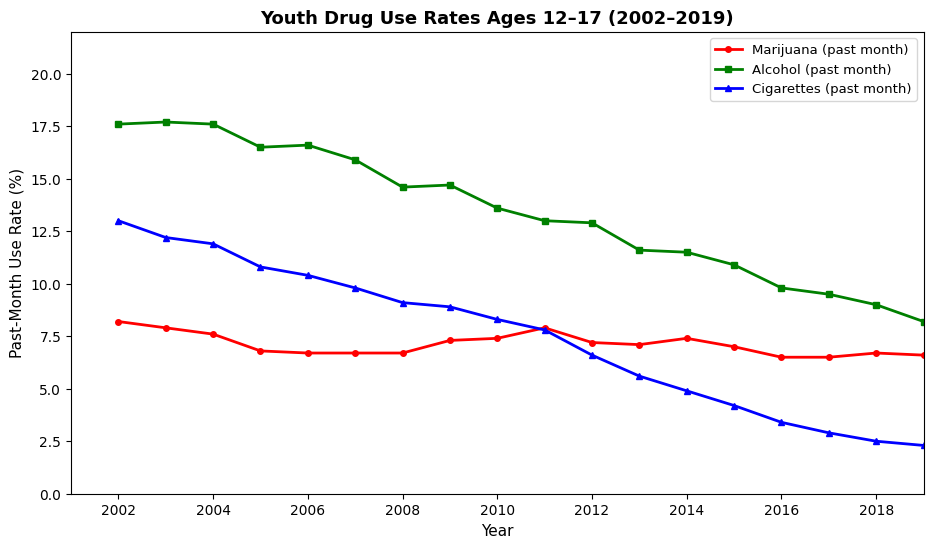

In [32]:
# Create a figure and set of axes for plot
fig, ax = plt.subplots(figsize=(11, 6))

# Marijuana usage past month
ax.plot(nsduh_df['year'], nsduh_df['marijuana_past_month_pct'],
        color = 'red', linewidth = 2, marker = 'o', markersize = 4,
        label = 'Marijuana (past month)')

# Alcohol usage past month
ax.plot(nsduh_df['year'], nsduh_df['alcohol_past_month_pct'],
        color = 'green', linewidth = 2, marker = 's', markersize = 4,
        label = 'Alcohol (past month)')

# Cigarettes usage past month
ax.plot(nsduh_df['year'], nsduh_df['cigarette_past_month_pct'],
        color = 'blue', linewidth = 2, marker = '^', markersize = 4,
        label = 'Cigarettes (past month)')

ax.set_title(
    'Youth Drug Use Rates Ages 12–17 (2002–2019)',
    fontsize = 13, fontweight = 'bold'
)
ax.set_xlabel('Year', fontsize = 11)
ax.set_ylabel('Past-Month Use Rate (%)', fontsize = 11)
ax.set_xlim(2001, 2019)
ax.set_ylim(0, 22)
ax.legend(loc='upper right', fontsize=9.5)

plt.show()

# Visualization 2
This scatterplot compares income and teen drug use rates. We can see if there is a visible correlation between the variables, which could also help us examine whether or not socioeconomic conditions influence substance use or how effective drug prevention programs are.

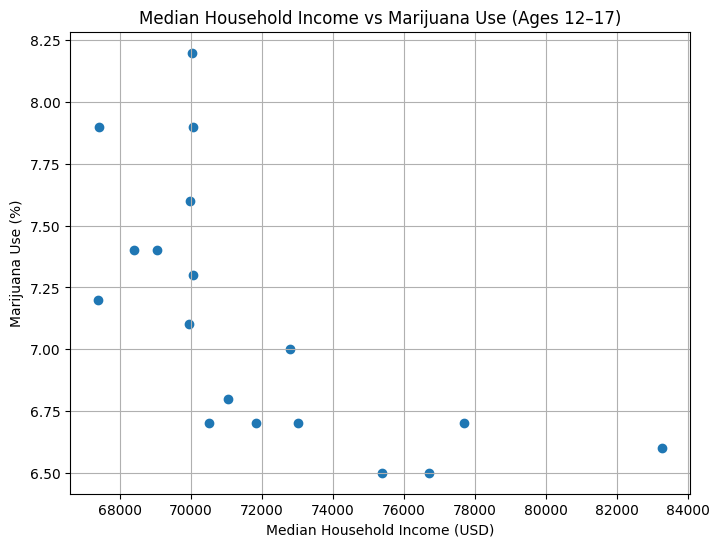

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(merged_df['median_household_income'], merged_df['marijuana_past_month_pct'])

plt.title('Median Household Income vs Marijuana Use (Ages 12–17)')
plt.xlabel('Median Household Income (USD)')
plt.ylabel('Marijuana Use (%)')
plt.grid(True)

plt.show()

# Visualization 3
This correlation heat map shows potential relationships between all variables. We can see correlation coefficients between median household income and various types of adolescent substance use variables (alcohol, cigarettes, marijuana). This will show us if there is a correlation between socioeconomic conditions and drug use.

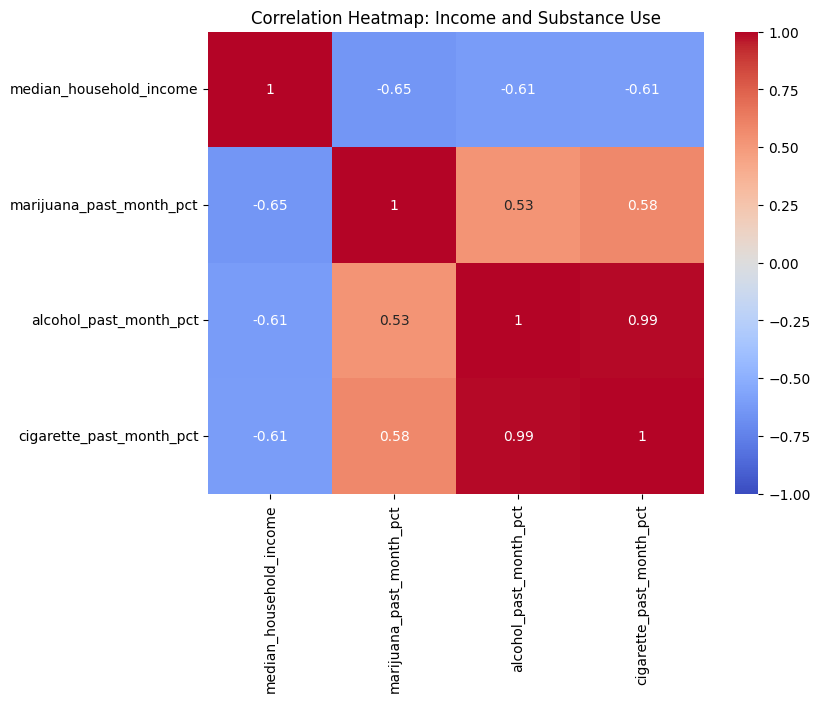

In [38]:
plt.figure(figsize=(8,6))

corr = merged_df[['median_household_income',
                  'marijuana_past_month_pct',
                  'alcohol_past_month_pct',
                  'cigarette_past_month_pct']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation Heatmap: Income and Substance Use')
plt.show()

# Visualization 4
This cross-tabulation compares high/low income years and high/low marijuana use years. By grouping income and marijuana use levels into categories, we may see patterns between the variables that were not as obvious using the raw data for years.

use_group     High Use  Low Use
income_group                   
Low Income           9        0
High Income          0        9


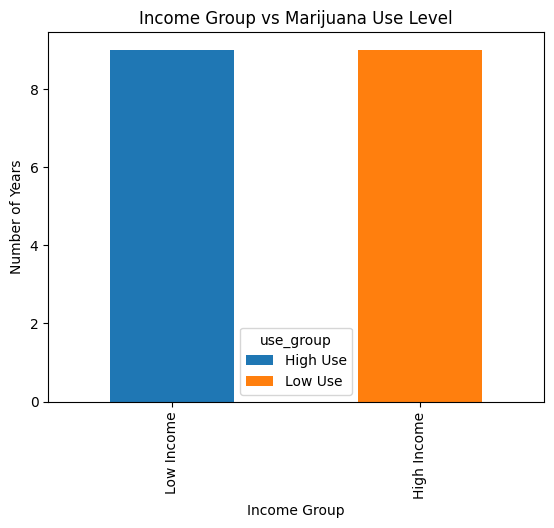

In [42]:
# create income categories
merged_df['income_group'] = pd.qcut(
    merged_df['median_household_income'],
    q=2,
    labels=['Low Income', 'High Income']
)

# create marijuana use categories (split at the median use level)
median_use = merged_df['marijuana_past_month_pct'].median()

merged_df['use_group'] = merged_df['marijuana_past_month_pct'].apply(
    lambda x: 'High Use' if x >= median_use else 'Low Use'
)

# return crosstab table
ct = pd.crosstab(merged_df['income_group'], merged_df['use_group'])
print(ct)

# plot crosstab
ct.plot(kind='bar', stacked=True)
plt.title('Income Group vs Marijuana Use Level')
plt.xlabel('Income Group')
plt.ylabel('Number of Years')
plt.show()

# Closing Thoughts and Final Goals:
**Model Idea 1** - I plan to build a regression model to see whether median household income can predict teen drug use rates. I will examine whether changes in household income are associated with changes in marijuana, alcohol, and cigarette use for the age group of interest. This will help me to verify whether or not there is a significant relationship between these variables.

**Model Idea 2** - I plan to build a model that uses year as a predictor to model how substance use in youth changes over time. I would use year as the independent variable, and test to see if there is a significant positive or negative trend in substance use among youth. This will help me to verify if there is an actual long term shift in the trend, or if I am just seeing short term fluctuations.